In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configurations for clean presentation
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


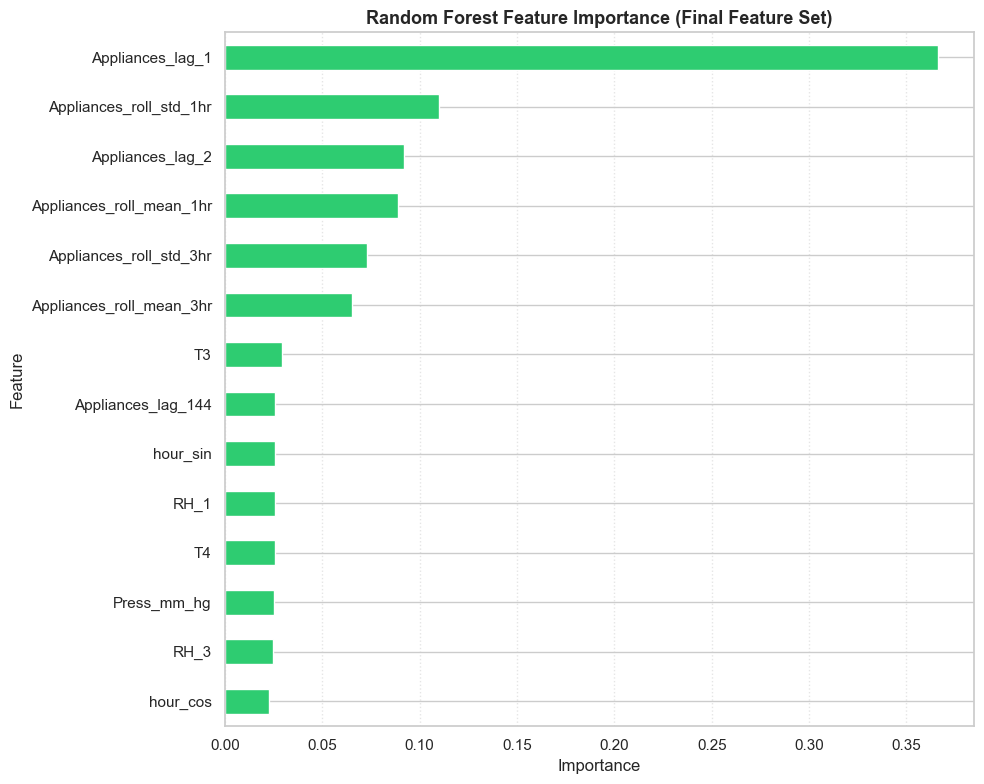

Appliances_lag_1            0.366409
Appliances_roll_std_1hr     0.109730
Appliances_lag_2            0.091895
Appliances_roll_mean_1hr    0.088861
Appliances_roll_std_3hr     0.073182
Appliances_roll_mean_3hr    0.065111
T3                          0.029177
Appliances_lag_144          0.025903
hour_sin                    0.025807
RH_1                        0.025693
T4                          0.025524
Press_mm_hg                 0.025247
RH_3                        0.024608
hour_cos                    0.022853
dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

rf = joblib.load(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\models\random_forest.pkl")

train = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\data\scaledfinal\train_unscaled_final.csv",
                     index_col='date', parse_dates=True)
drop_cols = ['Appliances', 'Appliances_log']
feature_cols = [c for c in train.columns if c not in drop_cols]

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='#2ecc71')
plt.title('Random Forest Feature Importance (Final Feature Set)', fontweight='bold', fontsize=13)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\reports\rf_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print(importances.sort_values(ascending=False))

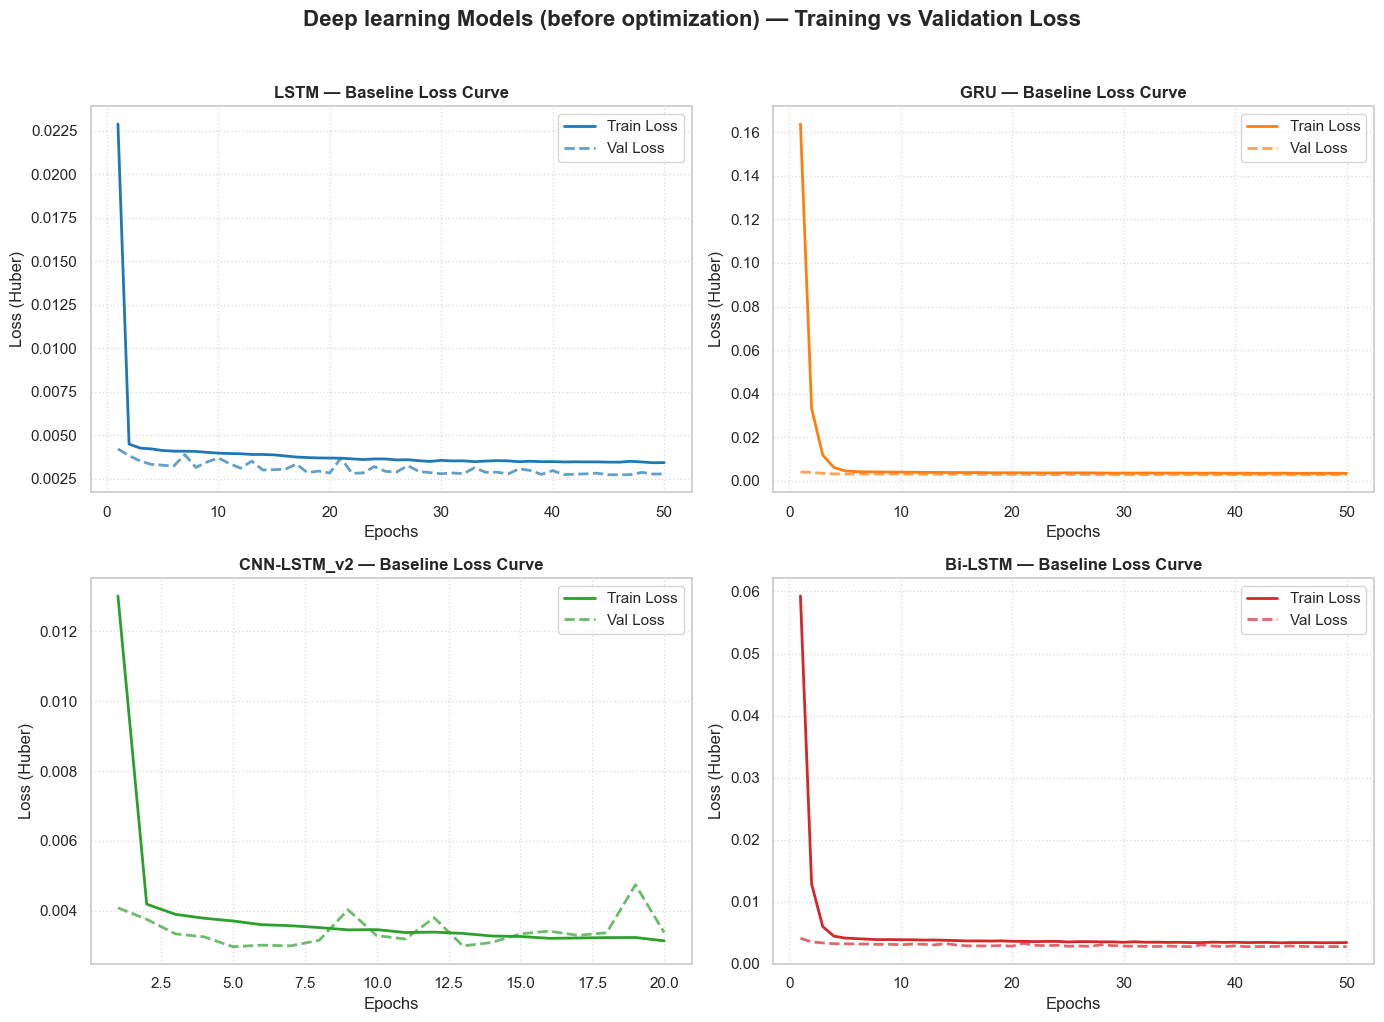

In [3]:
# Load initial training histories

with open(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\reports\initial_dl_histories.json", 'r') as f:
    base_histories = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = ['LSTM', 'GRU', 'CNN-LSTM_v2', 'Bi-LSTM']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, model in enumerate(models):
    if model in base_histories:
        hist = base_histories[model]
        epochs = range(1, len(hist['loss']) + 1)
        
        axes[i].plot(epochs, hist['loss'], label='Train Loss', color=colors[i], linewidth=2)
        axes[i].plot(epochs, hist['val_loss'], label='Val Loss', color=colors[i], linestyle='--', alpha=0.7, linewidth=2)
        
        axes[i].set_title(f'{model} — Baseline Loss Curve', fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel('Loss (Huber)')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Deep learning Models (before optimization) — Training vs Validation Loss', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

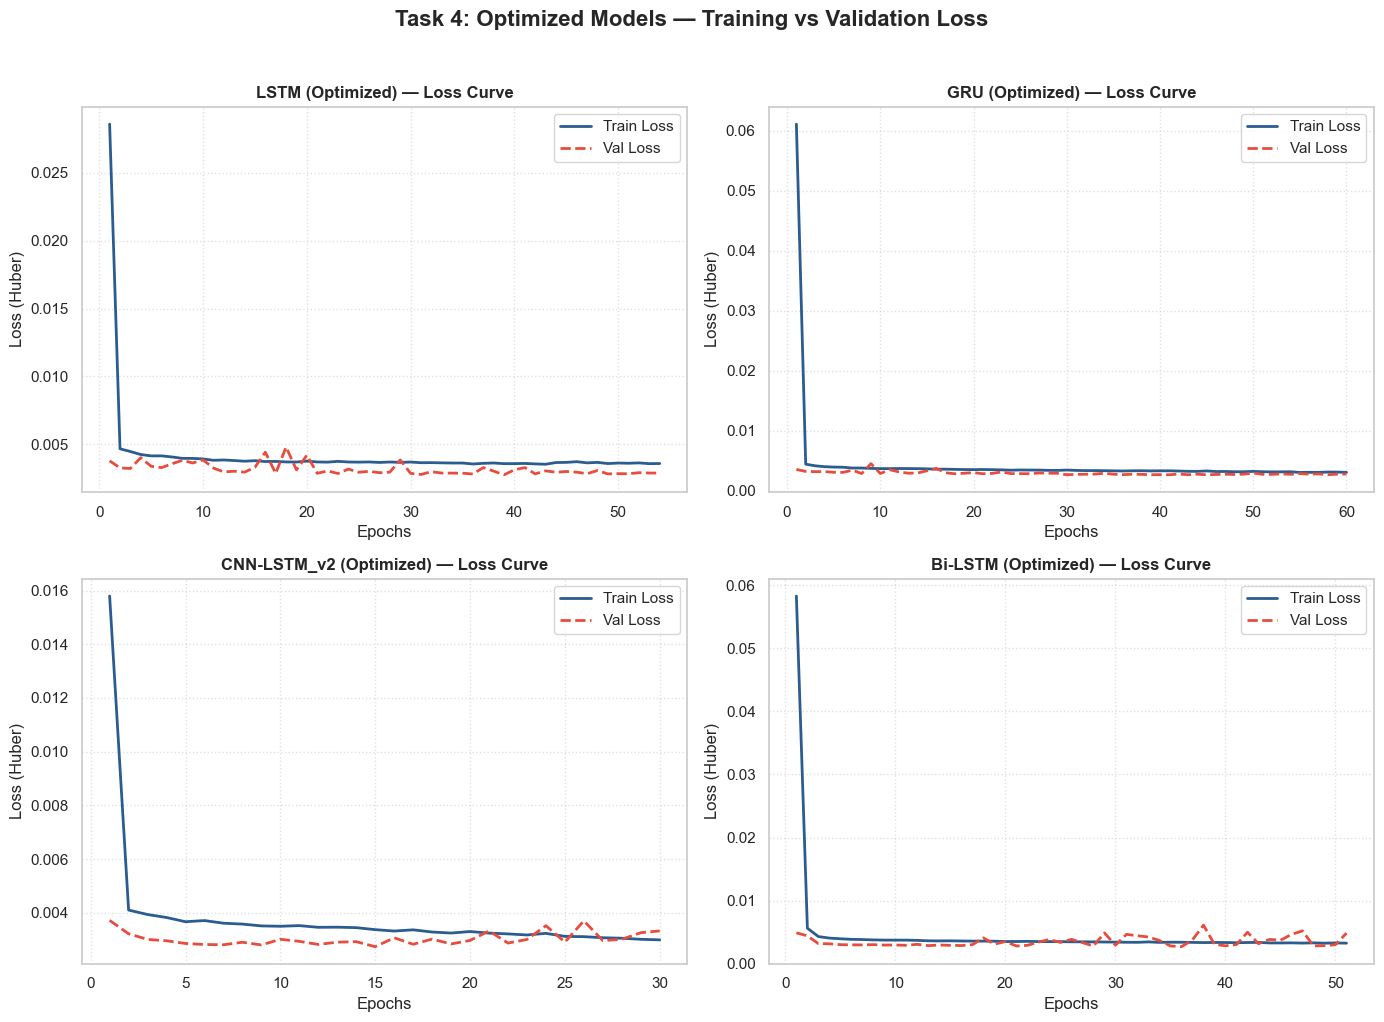

In [4]:
# Load optimized training histories
with open(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\reports\optimized_histories.json", 'r') as f:
    opt_histories = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, model in enumerate(models):
    if model in opt_histories:
        hist = opt_histories[model]
        epochs = range(1, len(hist['loss']) + 1)
        
        axes[i].plot(epochs, hist['loss'], label='Train Loss', color='#2b5c8f', linewidth=2)
        axes[i].plot(epochs, hist['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--', linewidth=2)
        
        axes[i].set_title(f'{model} (Optimized) — Loss Curve', fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel('Loss (Huber)')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Task 4: Optimized Models — Training vs Validation Loss', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

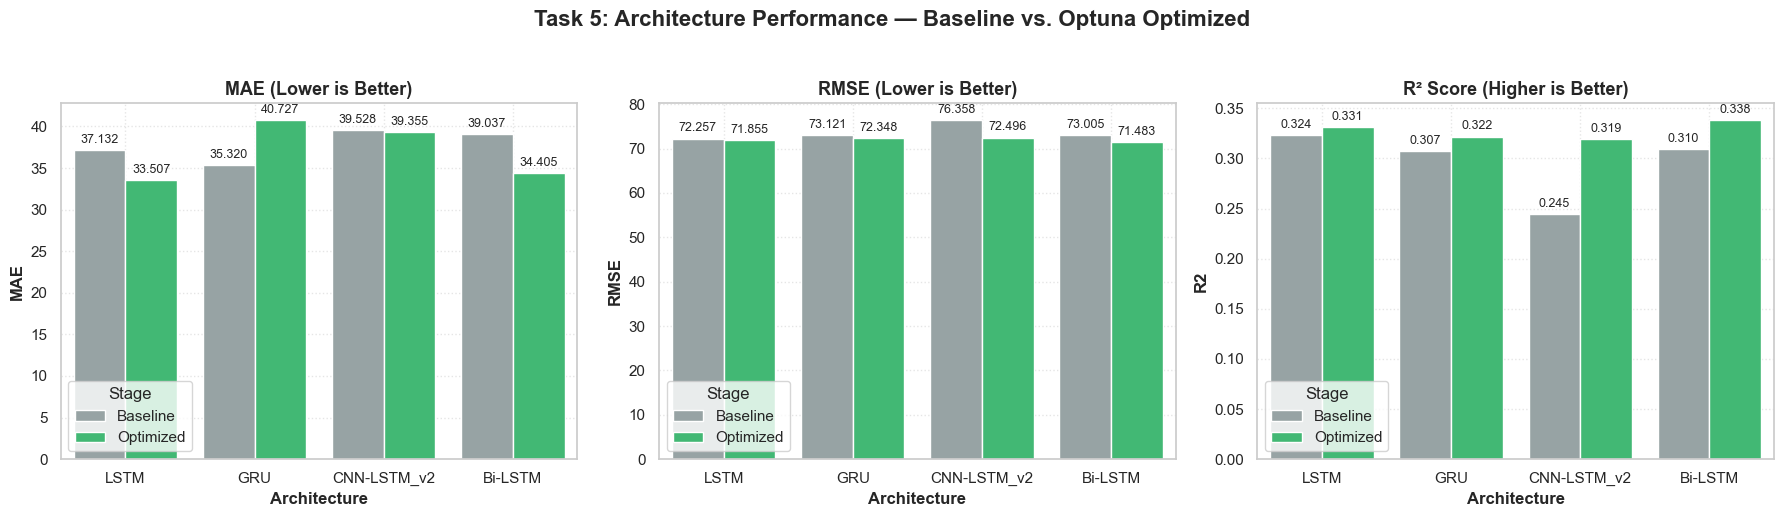

In [5]:
# Load metric CSVs
df_base = pd.read_csv(r'C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\reports\/deep_learning_comparison.csv')
df_opt = pd.read_csv(r'C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\reports\/deep_learning_optimized_results.csv')

# Standardize model names for side-by-side alignment
df_base['model_clean'] = df_base['model'].str.replace(' (Baseline)', '')
df_opt['model_clean'] = df_opt['model'].str.replace(' (Optimized)', '')

# Combine into long-format dataframe for seaborn
df_base['Stage'] = 'Baseline'
df_opt['Stage'] = 'Optimized'

combined_df = pd.concat([df_base, df_opt], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'R2']
titles = ['MAE (Lower is Better)', 'RMSE (Lower is Better)', 'R² Score (Higher is Better)']

for i, metric in enumerate(metrics):
    sns.barplot(
        data=combined_df, 
        x='model_clean', 
        y=metric, 
        hue='Stage', 
        ax=axes[i], 
        palette=['#95a5a6', '#2ecc71']
    )
    axes[i].set_title(titles[i], fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Architecture', fontweight='bold')
    axes[i].set_ylabel(metric, fontweight='bold')
    axes[i].grid(True, linestyle=':', alpha=0.5)
    
    # Value annotations on bars
    for p in axes[i].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[i].annotate(f'{height:.3f}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                             textcoords='offset points')

plt.suptitle('Task 5: Architecture Performance — Baseline vs. Optuna Optimized', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [6]:
# Create pivot summary table
summary_table = pd.merge(
    df_base[['model_clean', 'MAE', 'RMSE', 'R2']],
    df_opt[['model_clean', 'MAE', 'RMSE', 'R2']],
    on='model_clean',
    suffixes=(' (Base)', ' (Opt)')
)

# Sort by Best Optimized R2 Score
summary_table = summary_table.sort_values(by='R2 (Opt)', ascending=False).reset_index(drop=True)
summary_table.rename(columns={'model_clean': 'Model Architecture'}, inplace=True)

print("="*80)
print("FINAL SUMMARY: BEFORE VS. AFTER HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Display styled dataframe in notebook
display(summary_table.style.highlight_max(subset=['R2 (Base)', 'R2 (Opt)'], color="#1E2520")
                           .highlight_min(subset=['MAE (Opt)', 'RMSE (Opt)'], color="#1e221f")
                           .format("{:.4f}", subset=summary_table.columns[1:]))

FINAL SUMMARY: BEFORE VS. AFTER HYPERPARAMETER OPTIMIZATION


,Model Architecture,MAE (Base),RMSE (Base),R2 (Base),MAE (Opt),RMSE (Opt),R2 (Opt)
0,Bi-LSTM,39.0370,73.0050,0.3095,34.4048,71.4834,0.3380
1,LSTM,37.1321,72.2567,0.3236,33.5074,71.8547,0.3311
2,GRU,35.3200,73.1208,0.3073,40.7265,72.3476,0.3219
3,CNN-LSTM_v2,39.5282,76.3579,0.2446,39.3555,72.4963,0.3191


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [11:11:20] WARNING: C:\actions-runner\_work\xgboo

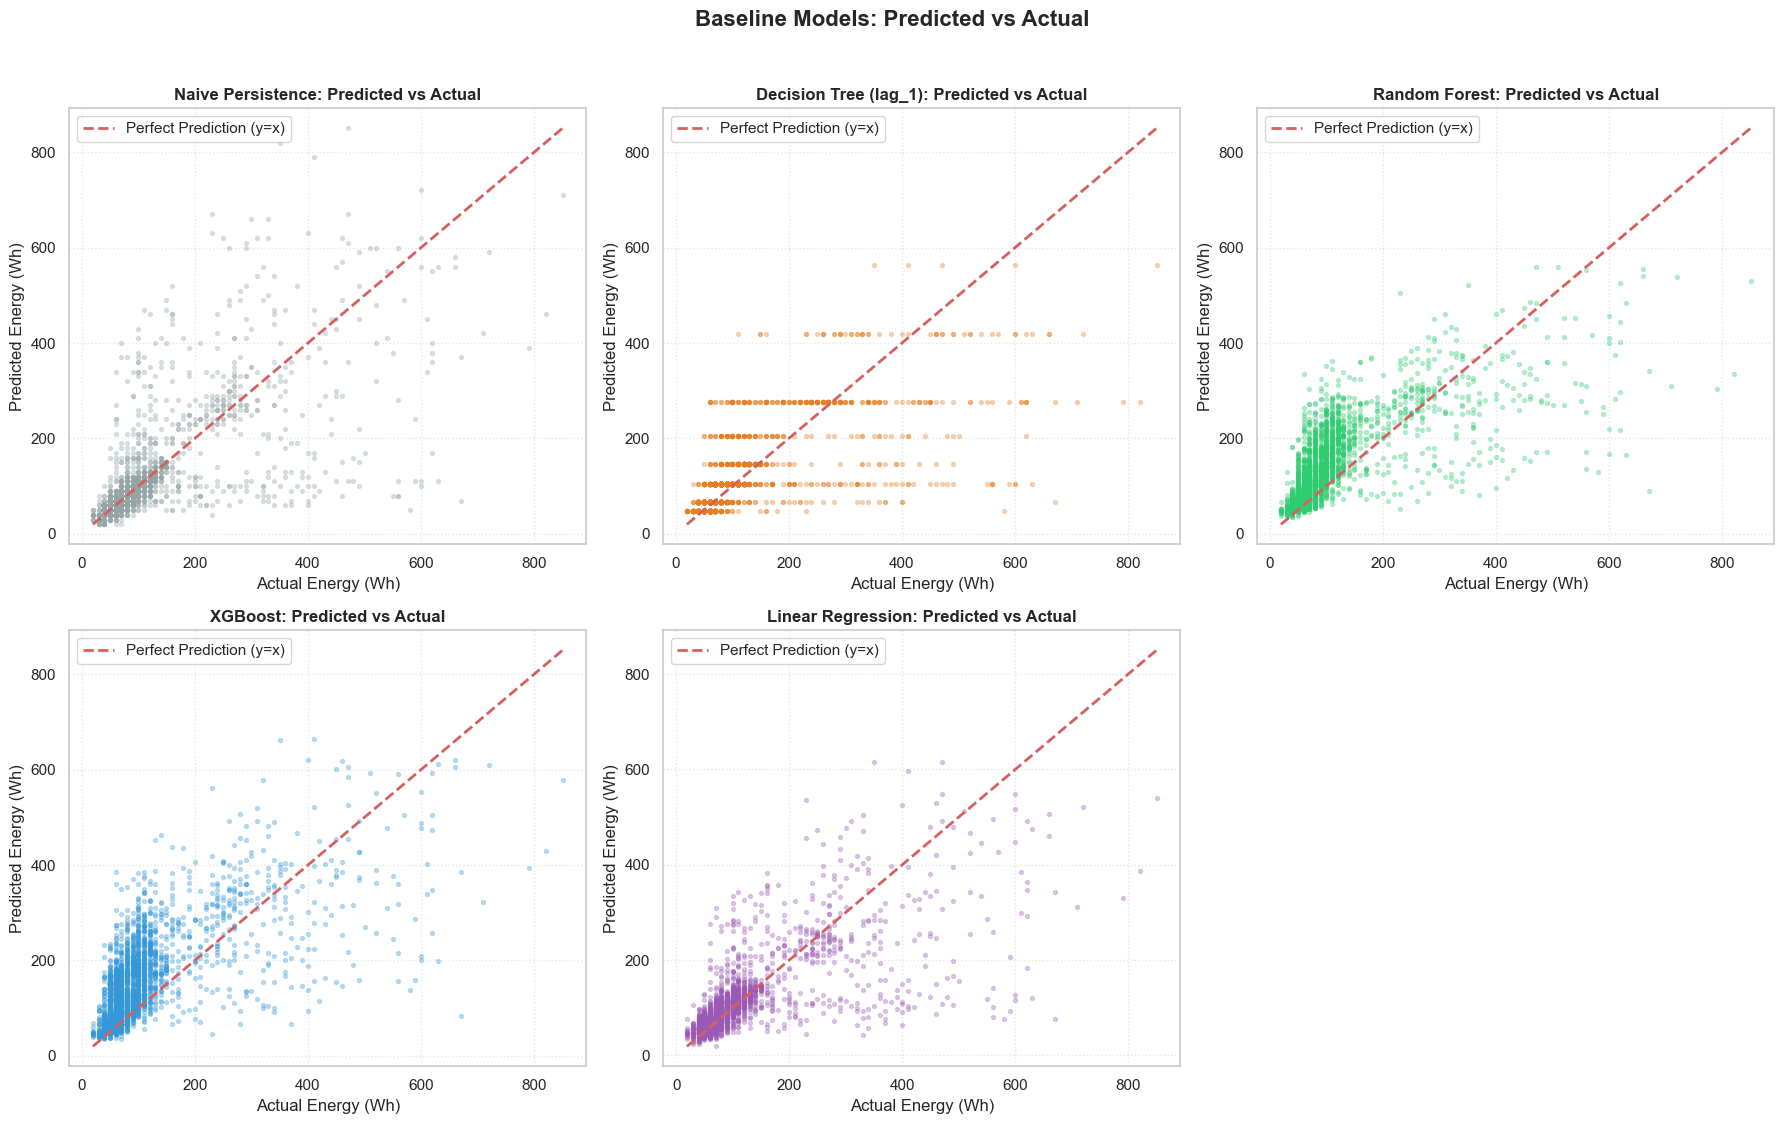

In [7]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

train = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\data\scaledfinal\train_unscaled_final.csv",
                     index_col='date', parse_dates=True)
test = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\data\scaledfinal\test_unscaled_final.csv",
                    index_col='date', parse_dates=True)

feature_cols = [c for c in train.columns if c not in ['Appliances', 'Appliances_log']]
X_train, y_train = train[feature_cols], train['Appliances']
X_test, y_test = test[feature_cols], test['Appliances']

rf = joblib.load(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\models\random_forest.pkl")
xgb = joblib.load(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\models\xgboost.pkl")
lr = joblib.load(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\models\linear_regression.pkl")

dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train[['Appliances_lag_1']], y_train)

baseline_preds = {
    'Naive Persistence': test['Appliances'].shift(1).iloc[1:].values,
    'Decision Tree (lag_1)': dt.predict(X_test[['Appliances_lag_1']]),
    'Random Forest': rf.predict(X_test),
    'XGBoost': xgb.predict(X_test),
    'Linear Regression': lr.predict(X_test),
}
baseline_true = {
    'Naive Persistence': test['Appliances'].iloc[1:].values,
    'Decision Tree (lag_1)': y_test.values,
    'Random Forest': y_test.values,
    'XGBoost': y_test.values,
    'Linear Regression': y_test.values,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
colors_b = ['#95a5a6', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

for i, (name, preds) in enumerate(baseline_preds.items()):
    true_vals = baseline_true[name]
    axes[i].scatter(true_vals, preds, alpha=0.3, s=8, color=colors_b[i])
    min_v, max_v = min(true_vals.min(), preds.min()), max(true_vals.max(), preds.max())
    axes[i].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction (y=x)')
    axes[i].set_title(f'{name}: Predicted vs Actual', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Actual Energy (Wh)')
    axes[i].set_ylabel('Predicted Energy (Wh)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.5)

axes[5].axis('off')  # unused 6th slot
plt.suptitle('Baseline Models: Predicted vs Actual', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

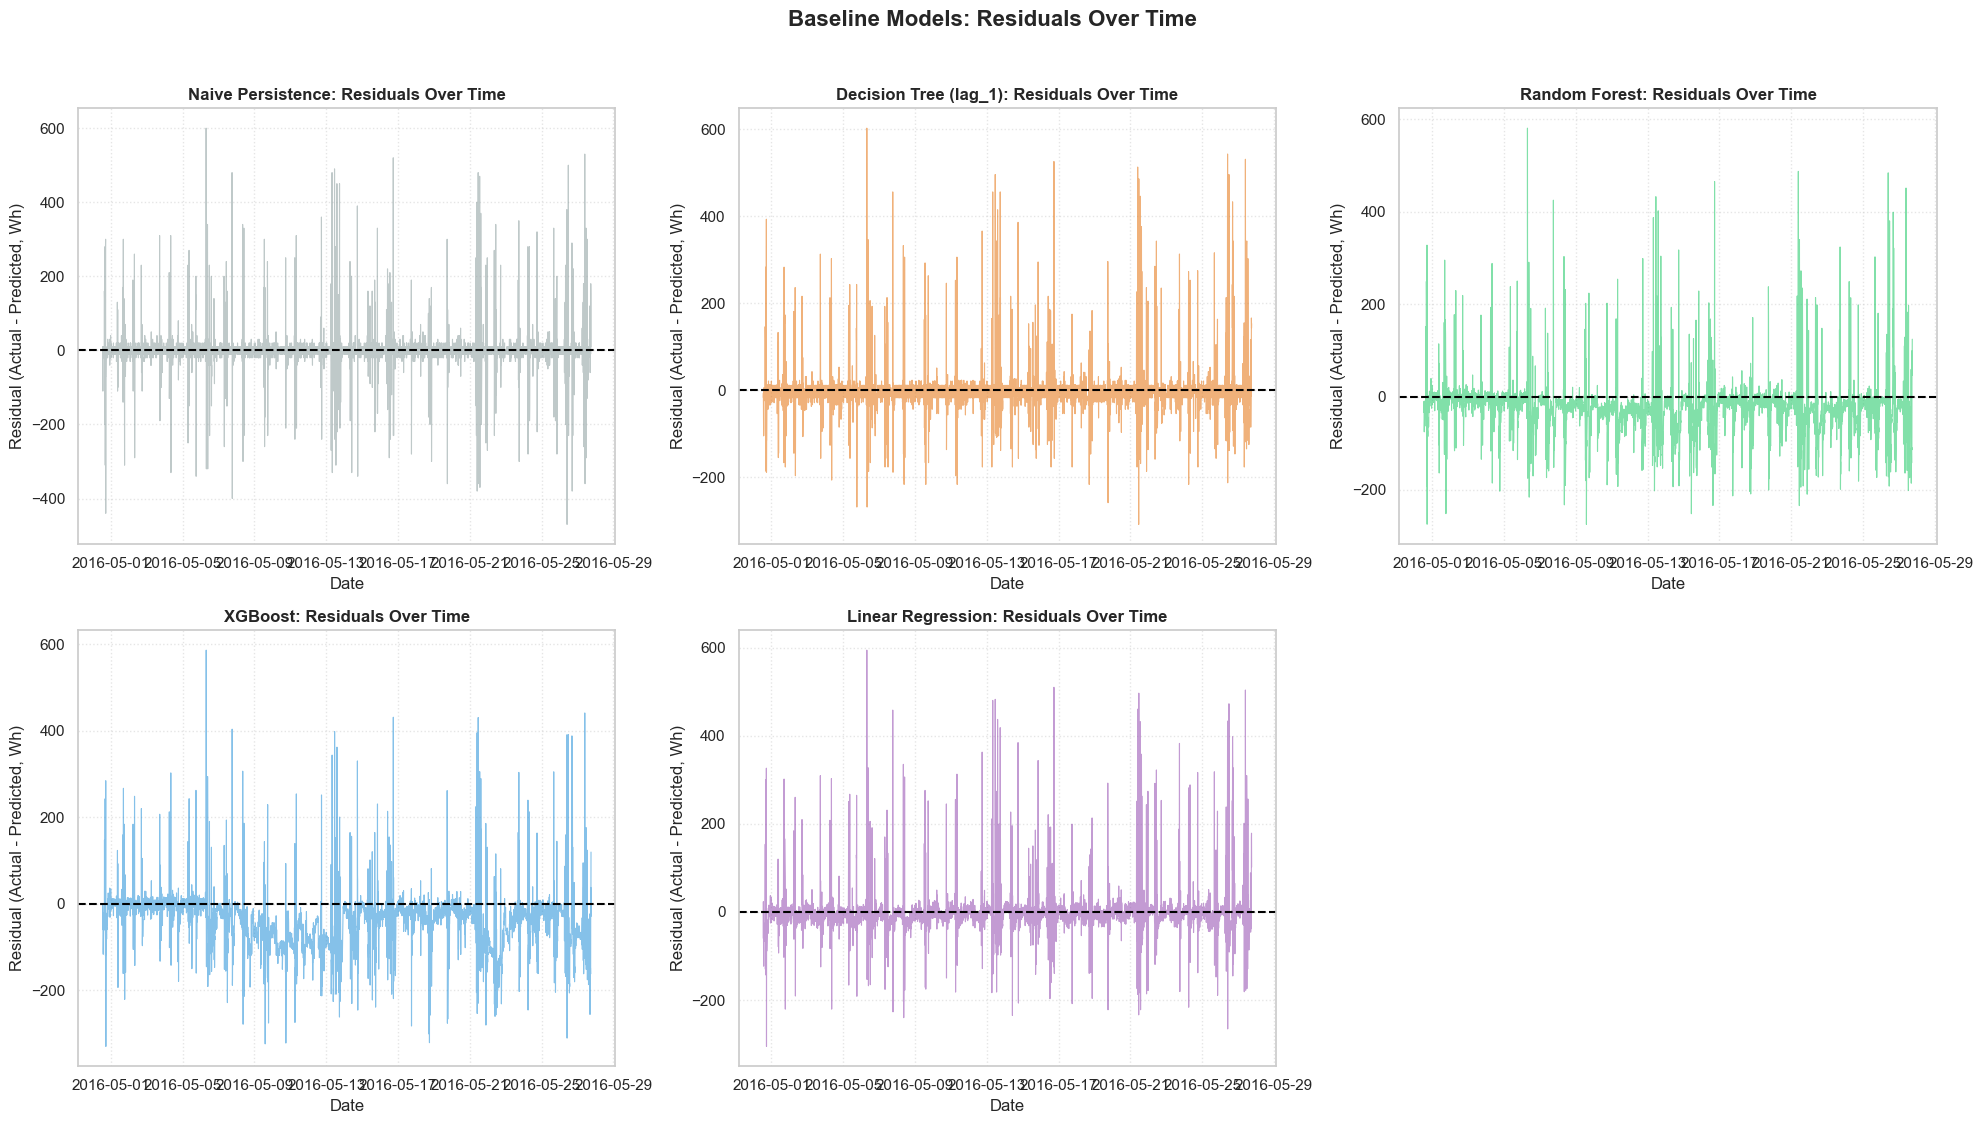

RESIDUAL SUMMARY — BASELINE MODELS
Naive Persistence      | mean:   0.043 | std:  65.178
Decision Tree (lag_1)  | mean:  -1.656 | std:  61.334
Random Forest          | mean: -25.469 | std:  61.408
XGBoost                | mean: -41.320 | std:  68.311
Linear Regression      | mean:   0.239 | std:  58.980


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

test_dates_naive = test.index[1:]
test_dates_full = test.index

date_map = {
    'Naive Persistence': test_dates_naive,
    'Decision Tree (lag_1)': test_dates_full,
    'Random Forest': test_dates_full,
    'XGBoost': test_dates_full,
    'Linear Regression': test_dates_full,
}

for i, (name, preds) in enumerate(baseline_preds.items()):
    true_vals = baseline_true[name]
    residuals = true_vals - preds
    dates = date_map[name]

    axes[i].plot(dates, residuals, alpha=0.6, linewidth=0.8, color=colors_b[i])
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{name}: Residuals Over Time', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Residual (Actual - Predicted, Wh)')
    axes[i].grid(True, linestyle=':', alpha=0.5)

axes[5].axis('off')
plt.suptitle('Baseline Models: Residuals Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 60)
print("RESIDUAL SUMMARY — BASELINE MODELS")
print("=" * 60)
for name, preds in baseline_preds.items():
    residuals = baseline_true[name] - preds
    print(f"{name:22s} | mean: {residuals.mean():7.3f} | std: {residuals.std():7.3f}")

In [9]:
# Load models and get predictions for all DL models
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np

# Load data and scaler
test = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\data\scaledfinal\test_unscaled_final.csv",
                   index_col='date', parse_dates=True)
test_scaled = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\data\scaledfinal\test_nn_scaled_final.csv",
                          index_col='date', parse_dates=True)
target_scaler = joblib.load(r"C:\Users\ASUS\OneDrive\Desktop\AI Intern Assessment\models\dl_target_scaler.pkl")

# Feature columns
feature_cols = [c for c in test.columns if c not in ['Appliances', 'Appliances_log']]

# Create sequences (seq_length=12)
def create_sequences(X, y, seq_len=12):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i - seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_test = test_scaled[feature_cols].values
y_test = target_scaler.transform(test[['Appliances']].values)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_len=12)

# Load all models
models = {
    'LSTM': 'models/lstm_model.keras',
    'GRU': 'models/gru_model.keras',
    'CNN-LSTM_v2': 'models/cnn_lstm_v2_model.keras',
    'Bi-LSTM': 'models/bi_lstm_model.keras'
}

predictions = {}
for name, path in models.items():
    model = load_model(path)
    y_pred_scaled = model.predict(X_test_seq, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_true = target_scaler.inverse_transform(y_test_seq)
    predictions[name] = {'true': y_true.flatten(), 'pred': y_pred.flatten()}

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: File not found: filepath=models/lstm_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, data) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(data['true'], data['pred'], alpha=0.3, s=10, color=colors[i])
    
    # Perfect prediction line
    min_val = min(data['true'].min(), data['pred'].min())
    max_val = max(data['true'].max(), data['pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
    
    # R² score
    from sklearn.metrics import r2_score
    r2 = r2_score(data['true'], data['pred'])
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{name}: Predicted vs Actual', fontweight='bold')
    ax.set_xlabel('Actual Energy (Wh)')
    ax.set_ylabel('Predicted Energy (Wh)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Deep Learning: Predicted vs Actual', fontsize=16, fontweight='bold')
plt.tight_layout()
\
plt.show()